In [1]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import optuna
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor
from Preprocess import preprocess_data_window
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)


c:\Users\kaitl\anaconda3\envs\icequake-qrc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Cell 2: Load data ────────────────────────────────────────────────────────
data_orig     = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")


In [ ]:
# ── Cell 3: Preprocessing ────────────────────────────────────────────────────
n_qubits_base = 6

X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data_chronological(
    filtered_time, data_orig)


print("NaN count per column:\n", X_train.isna().sum())
print("Total NaN:", X_train.isna().sum().sum())


X shape:  (2822, 126)
y shape:  (2822,)
NaN count per column:
 tide_deriv-0      0
form_fac-0        0
time_since-0      0
slip_size-0       0
high_t_evt-0      0
                 ..
form_fac-20       0
time_since-20     0
slip_size-20      0
high_t_evt-20     0
tide_height-20    0
Length: 126, dtype: int64
Total NaN: 0


In [ ]:
# ── Cell 4: Config ───────────────────────────────────────────────────────────
QRC_CONFIG = {
    "num_layers_per_event": 2, 
    "shots":4096,
    "n_iterations": 5,
    "top_k": 3,
    "correlation_threshold": 0.0,
    "random_seed": 42,
}

CLASSICAL_MODEL_NAME = "Ridge"

print("QRC Config:", QRC_CONFIG)
print("Classical model:", CLASSICAL_MODEL_NAME)


QRC Config: {'num_layers_per_event': 2, 'shots': 4096, 'n_iterations': 5, 'top_k': 3, 'correlation_threshold': 0.0, 'random_seed': 42}
Classical model: Ridge


In [5]:
# ── Cell 5: Scaling ─────────────────────────────────────────────────────────
def scale_to_pi_range(X_train, X_val, X_test):
    train_min = X_train.min(axis=0)
    train_max = X_train.max(axis=0)
    denom = train_max - train_min
    denom[denom == 0] = 1.0

    def transform(X):
        scaled = (X - train_min) / denom
        scaled = np.clip(scaled, 0.0, 1.0)
        return scaled * np.pi

    return transform(X_train), transform(X_val), transform(X_test)


X_train_sel = X_train.to_numpy()
X_val_sel   = X_val.to_numpy()
X_test_sel  = X_test.to_numpy()

X_train_q, X_val_q, X_test_q = scale_to_pi_range(X_train_sel, X_val_sel, X_test_sel)

# Convert targets to numpy once here for use throughout
y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.array(y_train)
y_val_np   = y_val.to_numpy()   if hasattr(y_val,   "to_numpy") else np.array(y_val)
y_test_np  = y_test.to_numpy()  if hasattr(y_test,  "to_numpy") else np.array(y_test)

n_qubits       = n_qubits_base
n_states       = 2 ** n_qubits
n_total_events = n_previous_events + 1

print(f"Input to quantum circuit: {X_train_q.shape}")
print(f"n_qubits: {n_qubits}, n_states: {n_states}")
print(f"Total events per sample: {n_total_events}")


Input to quantum circuit: (1692, 126)
n_qubits: 6, n_states: 64
Total events per sample: 21


In [ ]:
# ── Cell 6: Regime labels 

import re
import numpy as np
import pandas as pd


REGIME_LABELS_PATH = "ridge_noiseless_fc_classifier_events.csv"

# ── Step 1: Parse the comment header for the K-Means cluster centers/boundary ─
with open(REGIME_LABELS_PATH, "r") as f:
    header_line = f.readline()

m = re.search(
    r"short_center_s=([\d.eE+-]+)\s+long_center_s=([\d.eE+-]+)\s+boundary_s=([\d.eE+-]+)",
    header_line,
)
if m is None:
    raise ValueError(f"Could not parse cluster centers from header line: {header_line!r}")

short_center_s, long_center_s, boundary_s = (float(g) for g in m.groups())
centers  = np.array([short_center_s, long_center_s])
boundary = boundary_s

print(f"Loaded regime centers — Short: {centers[0]:.0f} s, Long: {centers[1]:.0f} s")
print(f"Decision boundary (from file): {boundary:.0f} s")

# ── Step 2: Load the per-event labels 
regime_df = pd.read_csv(REGIME_LABELS_PATH, skiprows=1, sep=None, engine="python")

regime_df.columns = [str(c).strip() for c in regime_df.columns]
regime_df = regime_df.loc[:, ~regime_df.columns.str.match(r"^Unnamed")]
regime_df = regime_df.dropna(axis=1, how="all")

required_cols = {"split", "event_index", "y_true_ttns_s", "regime_label", "regime"}
missing = required_cols - set(regime_df.columns)
if missing:
    raise ValueError(
        f"Regime labels file is missing expected columns: {missing}\n"
        f"Columns actually found: {list(regime_df.columns)}\n"
        f"Check REGIME_LABELS_PATH and the file's delimiter/header row."
    )

regime_df["split"]         = regime_df["split"].astype(str).str.strip()
regime_df["event_index"]   = pd.to_numeric(regime_df["event_index"])
regime_df["y_true_ttns_s"] = pd.to_numeric(regime_df["y_true_ttns_s"])
regime_df["regime_label"]  = pd.to_numeric(regime_df["regime_label"]).astype(int)

def _labels_for_split(split_name, X_split, y_split_np):
    sub = (
        regime_df[regime_df["split"] == split_name]
        .sort_values("event_index")
        .reset_index(drop=True)
    )
    if len(sub) != len(X_split):
        raise ValueError(
            f"'{split_name}' split length mismatch: file has {len(sub)} rows, "
            f"but X_{split_name} has {len(X_split)} rows. Check that the file "
            f"was generated from the same preprocessing/split as this notebook."
        )
    file_y = sub["y_true_ttns_s"].to_numpy()
    if not np.allclose(file_y, y_split_np, atol=1e-6):
        n_mismatch = int(np.sum(~np.isclose(file_y, y_split_np, atol=1e-6)))
        print(
            f"  WARNING: {n_mismatch}/{len(file_y)} '{split_name}' y-values differ "
            f"between the file and this notebook's y_{split_name}. The two may not "
            f"be row-aligned — double-check event_index ordering before trusting "
            f"downstream results."
        )
    else:
        print(f"  '{split_name}' labels verified against y_{split_name} ({len(sub)} rows match).")
    return sub["regime_label"].to_numpy().astype(int)

# Only the test-split labels are needed downstream (diagnostic plot coloring).
clf_test_labels = _labels_for_split("test", X_test, y_test_np)

print(f"Regime label distribution (test, diagnostic/plotting only) — "
      f"Short: {(clf_test_labels==0).sum()}, Long: {(clf_test_labels==1).sum()}")


In [ ]:
# ── Cell 7: FC-TFI Hamiltonian ────────────────────────────────────────────────


def generate_ising_params(n_qubits, rng, J_std=0.5, h=1.0, t=0.5):
    """Draw a single random all-to-all coupling matrix J (plus fixed h, t)."""
    J = np.zeros((n_qubits, n_qubits))
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            J[i, j] = rng.normal(0, J_std)
    return J, h, t


def trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=3):
    dt = t / n_trotter_steps
    for _ in range(n_trotter_steps):
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                if abs(J[i, j]) > 1e-10:
                    qc.cx(i, j)
                    qc.rz(2 * J[i, j] * dt, j)
                    qc.cx(i, j)
        for i in range(n_qubits):
            qc.rx(2 * h * dt, i)


def encode_rotations(qc, data_sample, n_qubits):
    for i in range(n_qubits):
        qc.ry(float(data_sample[i]), i)


In [ ]:
# ── Cell 8: Sequential  FC-TFI reservoir 
from qiskit.quantum_info import Statevector, SparsePauliOp

def build_event_step_circuit(data_sample, ising_params, num_layers, n_qubits, apply_initial_h):
    J, h, t = ising_params
    qc = QuantumCircuit(n_qubits)
    if apply_initial_h:
        for i in range(n_qubits):
            qc.h(i)
    encode_rotations(qc, data_sample, n_qubits)
    for _ in range(num_layers):
        trotter_ising_layer(qc, n_qubits, J, h, t)
        encode_rotations(qc, data_sample, n_qubits)
        trotter_ising_layer(qc, n_qubits, J, h, t)
    return qc


def pauli_expectations_from_statevector(sv, n_qubits):
    # Exact expectation values
    expectations = np.zeros(3 * n_qubits)
    for basis_idx, basis in enumerate(['Z', 'X', 'Y']):
        for q in range(n_qubits):
            label = ['I'] * n_qubits
            label[n_qubits - 1 - q] = basis
            op = SparsePauliOp(''.join(label))
            expectations[basis_idx * n_qubits + q] = sv.expectation_value(op).real

    zz_correlators = np.zeros(n_qubits)
    for i in range(n_qubits):
        j = (i + 1) % n_qubits
        label = ['I'] * n_qubits
        label[n_qubits - 1 - i] = 'Z'
        label[n_qubits - 1 - j] = 'Z'
        op = SparsePauliOp(''.join(label))
        zz_correlators[i] = sv.expectation_value(op).real

    return np.concatenate([expectations, zz_correlators])


def run_quantum_reservoir_pauli_sequential(
    X_data, ising_params, num_layers, n_qubits, n_total_events
):
    """Evolves ONE running statevector per sample across all n_total_events,
    injecting data via Ry rotations and evolving under the SAME fixed
    (J, h, t) Hamiltonian at every step. The state is never reset between
    encodings within a sample."""
    if hasattr(X_data, 'values'):
        X_data = X_data.to_numpy()

    m     = X_data.shape[0]
    n_obs = 3 * n_qubits + n_qubits
    pauli_matrix = np.zeros((m, n_total_events * n_obs))

    for sample_idx in range(m):
        sv = Statevector.from_label('0' * n_qubits)

        for event_idx in range(n_total_events):
            start_col = event_idx * n_qubits
            end_col   = start_col + n_qubits
            data_sample = X_data[sample_idx, start_col:end_col]

            step_circuit = build_event_step_circuit(
                data_sample, ising_params, num_layers, n_qubits,
                apply_initial_h=(event_idx == 0),
            )
            sv = sv.evolve(step_circuit)   # <-- state persists, no reset

            obs_vals = pauli_expectations_from_statevector(sv, n_qubits)
            pauli_matrix[
                sample_idx,
                event_idx * n_obs:(event_idx + 1) * n_obs
            ] = obs_vals

        if sample_idx % 50 == 0:
            print(f"  Sample {sample_idx + 1}/{m} done", end="\r")

    print()
    return pauli_matrix


In [9]:
# ── Cell 9: Model registry ────────────────────────────────────────────────────
def get_model_registry():
    return {
        "Ridge": {
            "optuna_fn": lambda trial: {
                "alpha": trial.suggest_float("alpha", 1e-2, 1e8, log=True),
            },
            "fixed_params": {},
            "build_fn": lambda params: Ridge(**params),
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "linear",
        },
        "XGBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
                "max_depth":        trial.suggest_int("max_depth", 2, 8),
                "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
                "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            },
            "fixed_params": {
                "objective":   "reg:squarederror",
                "n_estimators": 2000,
                "random_state": 42,
                "tree_method":  "hist",
            },
            "build_fn": lambda params: XGBRegressor(**params),
            # optuna_fit_fn: plain fit — used only inside Optuna CV objectives.
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt, verbose=False),
            # fit_fn: plain fit, no eval_set, no early stopping.
            # n_estimators is fixed; val is kept clean for iteration ranking.
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt, verbose=False),
            "shap_explainer": "tree",
        },
        "CatBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "depth":         trial.suggest_int("depth", 2, 8),
            },
            "fixed_params": {
                "iterations":          100,
                "loss_function":       "RMSE",
                "eval_metric":         "RMSE",
                "random_seed":         42,
                "verbose":             False,
                "allow_writing_files": False,
            },
            "build_fn": lambda params: CatBoostRegressor(**params),
            # plain fit, no eval_set 
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "tree",
        },
        "RandomForest": {
            "optuna_fn": lambda trial: {
                "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
                "max_depth":    trial.suggest_int("max_depth", 2, 10),
            },
            "fixed_params": {"random_state": 42},
            "build_fn": lambda params: RandomForestRegressor(**params),
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "tree",
        },
    }


registry = get_model_registry()
print(f"Available models: {list(registry.keys())}")
print(f"Using: {CLASSICAL_MODEL_NAME}")


Available models: ['Ridge', 'XGBoost', 'CatBoost', 'RandomForest']
Using: Ridge


In [ ]:
# ── Cell 10: Single iteration — ONE shared FC-TFI reservoir, ONE regressor ───
def run_single_qrc_iteration(
    iteration_idx,
    H_train, H_val, H_test,
    y_train_np, y_val_np, y_test_np,
    config, model_name, registry,
):
    seed  = config["random_seed"] + iteration_idx
    entry = registry[model_name]

    from sklearn.model_selection import KFold
    _n_cv_folds = 3

    def _cv_mae(params, rng_seed):
        kf   = KFold(n_splits=_n_cv_folds, shuffle=True, random_state=rng_seed)
        maes = []
        optuna_fit = entry.get("optuna_fit_fn", lambda m, Xt, yt: m.fit(Xt, yt))
        for fold_tr, fold_vl in kf.split(H_train):
            m = entry["build_fn"](params)
            optuna_fit(m, H_train[fold_tr], y_train_np[fold_tr])
            maes.append(mean_absolute_error(y_train_np[fold_vl], m.predict(H_train[fold_vl])))
        return float(np.mean(maes))

    def objective(trial):
        tuned  = entry["optuna_fn"](trial)
        params = {**entry["fixed_params"], **tuned}
        return _cv_mae(params, seed)

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed),
    )
    study.optimize(objective, n_trials=30)

    # Final refit on full train split; val used only for early stopping (fit_fn dependent)
    tuned  = entry["optuna_fn"](study.best_trial)
    params = {**entry["fixed_params"], **tuned}
    model  = entry["build_fn"](params)
    entry["fit_fn"](model, H_train, y_train_np, H_val, y_val_np)

    val_pred  = model.predict(H_val)
    test_pred = model.predict(H_test)

    val_mae = mean_absolute_error(y_val_np, val_pred)
    print(f"  Val MAE: {val_mae:.2f}s")

    return {
        "iteration":   iteration_idx,
        "val_r2":      r2_score(y_val_np, val_pred),
        "val_rmse":    root_mean_squared_error(y_val_np, val_pred),
        "val_mae":     val_mae,
        "test_rmse":   root_mean_squared_error(y_test_np, test_pred),
        "test_mae":    mean_absolute_error(y_test_np, test_pred),
        "test_pred":   test_pred,
        "best_params": params,
        "model":       model,
    }


In [ ]:
# ── Cell 11: Pipeline + run — single reservoir (fixed J), single regressor ───
def run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train_np, y_val_np, y_test_np,
    n_qubits, config, model_name, registry,
):
    num_layers     = config["num_layers_per_event"]
    n_total_events = n_previous_events + 1

    reservoir_rng = np.random.default_rng(config["random_seed"])
    ising_params  = generate_ising_params(n_qubits, reservoir_rng)

    print("Running the FC-TFI reservoir once per split (fixed J, reused across iterations)...")
    print(f"  Train ({len(X_train_q)} samples)...")
    H_train = run_quantum_reservoir_pauli_sequential(
        X_train_q, ising_params, num_layers, n_qubits, n_total_events
    )
    print(f"  Val ({len(X_val_q)} samples)...")
    H_val = run_quantum_reservoir_pauli_sequential(
        X_val_q, ising_params, num_layers, n_qubits, n_total_events
    )
    print(f"  Test ({len(X_test_q)} samples)...")
    H_test = run_quantum_reservoir_pauli_sequential(
        X_test_q, ising_params, num_layers, n_qubits, n_total_events
    )

    results = []
    for i in range(config["n_iterations"]):
        print(f"\nIteration {i + 1}/{config['n_iterations']}:")
        res = run_single_qrc_iteration(
            i,
            H_train, H_val, H_test,
            y_train_np, y_val_np, y_test_np,
            config, model_name, registry,
        )
        print(
            f"\tVal R2: {res['val_r2']:.4f} | Val RMSE: {res['val_rmse']:.2f} | "
            f"Val MAE: {res['val_mae']:.2f} | Test RMSE: {res['test_rmse']:.2f} | "
            f"Test MAE: {res['test_mae']:.2f}"
        )
        results.append(res)

    # ── Mean over all iterations ──────
    all_test_preds = np.array([r["test_pred"] for r in results])
    ensemble_pred  = all_test_preds.mean(axis=0)
    ensemble_rmse  = root_mean_squared_error(y_test_np, ensemble_pred)
    ensemble_mae   = mean_absolute_error(y_test_np, ensemble_pred)
    ensemble_r2    = r2_score(y_test_np, ensemble_pred)

    print(f"\nEnsemble (all {len(results)} iterations — primary headline):")
    print(f"  Test RMSE: {ensemble_rmse:.2f}")
    print(f"  Test MAE:  {ensemble_mae:.2f}")
    print(f"  Test R2:   {ensemble_r2:.4f}")

    # ── Secondary: top-k by val MAE ─
    top_k          = config["top_k"]
    sorted_results = sorted(results, key=lambda r: r["val_mae"])
    top_results    = sorted_results[:top_k]
    top_indices    = [r["iteration"] for r in top_results]

    top_k_pred = np.mean([r["test_pred"] for r in top_results], axis=0)
    top_k_rmse = root_mean_squared_error(y_test_np, top_k_pred)
    top_k_mae  = mean_absolute_error(y_test_np, top_k_pred)
    top_k_r2   = r2_score(y_test_np, top_k_pred)

    print(f"\nTop-{top_k} ensemble by val MAE (optimistic — val used for selection):")
    print(f"  Iterations: {[i + 1 for i in top_indices]}")
    print(f"  Test RMSE: {top_k_rmse:.2f}")
    print(f"  Test MAE:  {top_k_mae:.2f}")
    print(f"  Test R2:   {top_k_r2:.4f}")

    
    if "clf_test_labels" in globals():
        short_idx = np.where(clf_test_labels == 0)[0]
        long_idx  = np.where(clf_test_labels == 1)[0]
        print(f"\n=== Ensemble Test MAE by regime label (diagnostic only) ===")
        if len(short_idx) > 0:
            print(f"Short regime (n={len(short_idx)}): "
                  f"MAE = {mean_absolute_error(y_test_np[short_idx], ensemble_pred[short_idx]):.2f}s")
        if len(long_idx) > 0:
            print(f"Long  regime (n={len(long_idx)}): "
                  f"MAE = {mean_absolute_error(y_test_np[long_idx], ensemble_pred[long_idx]):.2f}s")

    return results, ensemble_pred, top_indices, ising_params


all_results, ensemble_pred, top_indices, ising_params = run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train_np, y_val_np, y_test_np,
    n_qubits, QRC_CONFIG,
    "Ridge",
    registry,
)


In [ ]:
# ── Cell 12: Classical XGBoost baseline (no classifier / regime split) ───────
import numpy as np
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold

X_train_np = X_train.to_numpy()
X_val_np   = X_val.to_numpy()
X_test_np  = X_test.to_numpy()

_N_CV = 3   # 3-fold CV

def _xgb_cv_rmse(X_tr, y_tr, params, n_folds=_N_CV, seed=42):
    """KFold CV-RMSE using plain fit (no eval_set) — leak-free objective."""
    kf    = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    rmses = []
    for tr_idx, vl_idx in kf.split(X_tr):
        m = XGBRegressor(**params, random_state=seed)
        m.fit(X_tr[tr_idx], y_tr[tr_idx], verbose=False)
        rmses.append(root_mean_squared_error(y_tr[vl_idx], m.predict(X_tr[vl_idx])))
    return float(np.mean(rmses))

_search_params = dict(objective="reg:squarederror", n_estimators=2000)

def objective_xgb(trial):
    params = {
        **_search_params,
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth":        trial.suggest_int("max_depth", 2, 5),
        "subsample":        trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
    }
    return _xgb_cv_rmse(X_train_np, y_train_np, params, seed=42)

opt_xgb = optuna.create_study(direction="minimize",
                               sampler=optuna.samplers.TPESampler(seed=42))
opt_xgb.optimize(objective_xgb, n_trials=30)
print("XGBoost optimal params:", opt_xgb.best_params)

# Final refit — no eval_set, no early stopping, val stays clean
XGBoost_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=2000,
    **opt_xgb.best_params,
    random_state=42,
)
XGBoost_model.fit(X_train_np, y_train_np, verbose=False)

final_predictions = XGBoost_model.predict(X_test_np)

overall_RMSE = root_mean_squared_error(y_test_np, final_predictions)
overall_MAE  = mean_absolute_error(y_test_np, final_predictions)

print("\n=== Classical XGBoost — Overall Test Performance ===")
print(f"RMSE: {overall_RMSE:.2f} s")
print(f"MAE:  {overall_MAE:.2f} s")


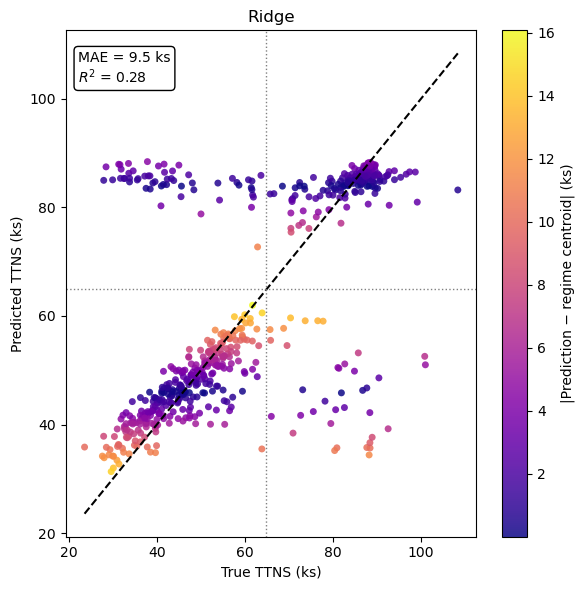

In [13]:
# ── Cell: Predicted vs True TTNS (Ridge QRC), single panel ────────────────────
import matplotlib.pyplot as plt

test_pred = ensemble_pred          # already computed by run_qrc_pipeline (Cell 12)
mae = mean_absolute_error(y_test_np, test_pred)
r2  = r2_score(y_test_np, test_pred)

# Regime centroid assigned to each test sample (from Cell 6's file-based labels)
assigned_center = np.where(clf_test_labels == 0, centers[0], centers[1])
color_vals = np.abs(test_pred - assigned_center) / 1000.0  # ks

fig, ax = plt.subplots(figsize=(6, 6))

sc = ax.scatter(
    y_test_np / 1000.0, test_pred / 1000.0,
    c=color_vals, cmap="plasma", s=25, alpha=0.85, edgecolors="none",
)

lims = [
    min(y_test_np.min(), test_pred.min()) / 1000.0,
    max(y_test_np.max(), test_pred.max()) / 1000.0,
]
ax.plot(lims, lims, "k--", linewidth=1.5)
ax.axhline(boundary / 1000.0, color="gray", linestyle=":", linewidth=1)
ax.axvline(boundary / 1000.0, color="gray", linestyle=":", linewidth=1)

ax.set_xlabel("True TTNS (ks)")
ax.set_ylabel("Predicted TTNS (ks)")
ax.set_title(f"{CLASSICAL_MODEL_NAME}")

ax.text(
    0.03, 0.96, f"MAE = {mae/1000:.1f} ks\n$R^2$ = {r2:.2f}",
    transform=ax.transAxes, va="top", fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="black"),
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("|Prediction − regime centroid| (ks)")

plt.tight_layout()
plt.show()

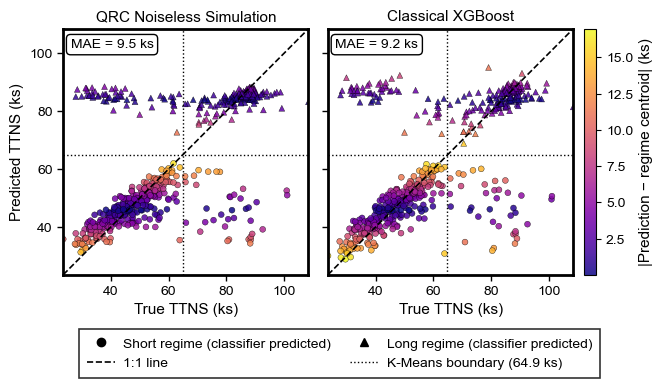

In [18]:
# ── Cell: Predicted vs True TTNS — QRC+Ridge vs. classical XGBoost ───────────
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ---------------------------------------------------------------- global style
mpl.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "font.style": "normal",
    "mathtext.default": "regular",
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 11,
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

# Panel 1: QRC + Ridge
qrc_pred = ensemble_pred
qrc_mae  = mean_absolute_error(y_test_np, qrc_pred)

# Panel 2: classical XGBoost baseline
xgb_pred = final_predictions
xgb_mae  = mean_absolute_error(y_test_np, xgb_pred)

assigned_center = np.where(clf_test_labels == 0, centers[0], centers[1])
qrc_color_vals = np.abs(qrc_pred - assigned_center) / 1000.0  # ks
xgb_color_vals = np.abs(xgb_pred - assigned_center) / 1000.0  # ks

vmin = min(qrc_color_vals.min(), xgb_color_vals.min())
vmax = max(qrc_color_vals.max(), xgb_color_vals.max())

lims = [
    min(y_test_np.min(), qrc_pred.min(), xgb_pred.min()) / 1000.0,
    max(y_test_np.max(), qrc_pred.max(), xgb_pred.max()) / 1000.0,
]

regime_marker = {0: "o", 1: "^"}

fig, axes = plt.subplots(1, 2, figsize=(6.89, 3.55), sharex=True, sharey=True)

panels = [
    (axes[0], "QRC Noiseless Simulation", qrc_pred, qrc_color_vals, qrc_mae),
    (axes[1], "Classical XGBoost",        xgb_pred, xgb_color_vals, xgb_mae),
]

sc = None
for ax, title, pred, color_vals, mae in panels:
    for regime in (0, 1):
        mask = clf_test_labels == regime
        sc = ax.scatter(
            y_test_np[mask] / 1000.0, pred[mask] / 1000.0,
            c=color_vals[mask], cmap="plasma",
            marker=regime_marker[regime],
            s=18, alpha=0.85,
            edgecolors="black", linewidths=0.3,
            vmin=vmin, vmax=vmax,
        )

    ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.2, zorder=1)
    ax.axhline(boundary / 1000.0, color="black", linestyle=":", linewidth=1.0, zorder=1)
    ax.axvline(boundary / 1000.0, color="black", linestyle=":", linewidth=1.0, zorder=1)

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("True TTNS (ks)")
    ax.set_title(title, fontweight="normal", fontstyle="normal")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(2)

    ax.grid(False)
    ax.tick_params(direction="out", width=1, length=4)

    # MAE-only annotation, tucked in the corner so it doesn't sit over data
    ax.text(
        0.03, 0.96, f"MAE = {mae/1000:.1f} ks",
        transform=ax.transAxes, va="top", fontsize=10,
        fontweight="normal", fontstyle="normal",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", linewidth=1),
    )

axes[0].set_ylabel("Predicted TTNS (ks)")

# ------------------------------------------------------------- boxed legend
legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="black",
           markeredgecolor="black", markersize=6,
           label="Short regime (classifier predicted)"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.2,
           label="1:1 line"),
    Line2D([0], [0], marker="^", color="none", markerfacecolor="black",
           markeredgecolor="black", markersize=6,
           label="Long regime (classifier predicted)"),
    Line2D([0], [0], color="black", linestyle=":", linewidth=1.0,
           label=f"K-Means boundary ({boundary/1000:.1f} ks)"),
]

fig.legend(
    handles=legend_handles, ncol=2, loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    frameon=True, edgecolor="black", fancybox=False,
    handletextpad=0.6, columnspacing=1.4, borderpad=0.6,
)
fig.legends[0].get_frame().set_linewidth(1.2)

fig.tight_layout(rect=[0, 0.05, 0.90, 1])
cbar = fig.colorbar(sc, ax=axes, fraction=0.03, pad=0.02)
cbar.set_label("|Prediction \u2212 regime centroid| (ks)")
cbar.ax.tick_params(labelsize=10)

# ---------------------------------------------------------------- save/export
fig.savefig("qrc_vs_xgb_ttns.png", dpi=600, bbox_inches="tight", pad_inches=0.02)

plt.show()

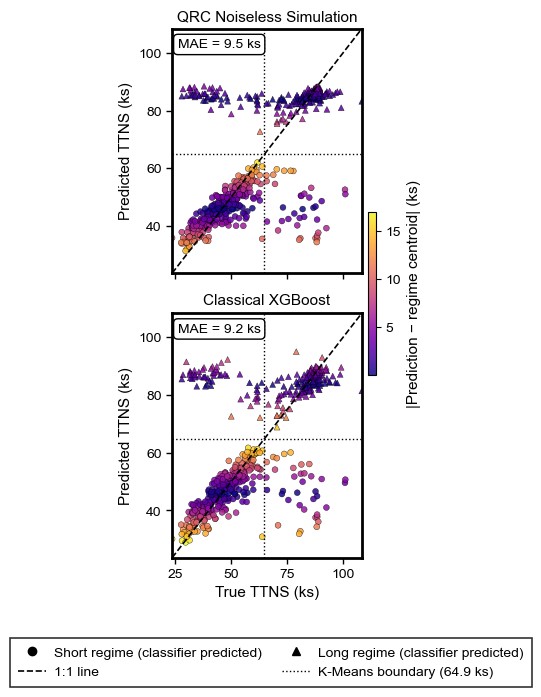

In [19]:
# ── Cell: Predicted vs True TTNS — QRC+Ridge vs. classical XGBoost ───────────
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ---------------------------------------------------------------- global style
mpl.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "font.style": "normal",
    "mathtext.default": "regular",
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 11,
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

# Panel 1: QRC + Ridge
qrc_pred = ensemble_pred
qrc_mae  = mean_absolute_error(y_test_np, qrc_pred)

# Panel 2: classical XGBoost baseline
xgb_pred = final_predictions
xgb_mae  = mean_absolute_error(y_test_np, xgb_pred)

assigned_center = np.where(clf_test_labels == 0, centers[0], centers[1])
qrc_color_vals = np.abs(qrc_pred - assigned_center) / 1000.0  # ks
xgb_color_vals = np.abs(xgb_pred - assigned_center) / 1000.0  # ks

vmin = min(qrc_color_vals.min(), xgb_color_vals.min())
vmax = max(qrc_color_vals.max(), xgb_color_vals.max())

lims = [
    min(y_test_np.min(), qrc_pred.min(), xgb_pred.min()) / 1000.0,
    max(y_test_np.max(), qrc_pred.max(), xgb_pred.max()) / 1000.0,
]

regime_marker = {0: "o", 1: "^"}

# Stacked vertically: single-column width, taller height for two rows
fig, axes = plt.subplots(2, 1, figsize=(3.34, 6.6), sharex=True, sharey=True)

panels = [
    (axes[0], "QRC Noiseless Simulation", qrc_pred, qrc_color_vals, qrc_mae),
    (axes[1], "Classical XGBoost",        xgb_pred, xgb_color_vals, xgb_mae),
]

sc = None
for ax, title, pred, color_vals, mae in panels:
    for regime in (0, 1):
        mask = clf_test_labels == regime
        sc = ax.scatter(
            y_test_np[mask] / 1000.0, pred[mask] / 1000.0,
            c=color_vals[mask], cmap="plasma",
            marker=regime_marker[regime],
            s=18, alpha=0.85,
            edgecolors="black", linewidths=0.3,
            vmin=vmin, vmax=vmax,
        )

    ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.2, zorder=1)
    ax.axhline(boundary / 1000.0, color="black", linestyle=":", linewidth=1.0, zorder=1)
    ax.axvline(boundary / 1000.0, color="black", linestyle=":", linewidth=1.0, zorder=1)

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_ylabel("Predicted TTNS (ks)")
    ax.set_title(title, fontweight="normal", fontstyle="normal")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(2)

    ax.grid(False)
    ax.tick_params(direction="out", width=1, length=4)

    ax.text(
        0.03, 0.96, f"MAE = {mae/1000:.1f} ks",
        transform=ax.transAxes, va="top", fontsize=10,
        fontweight="normal", fontstyle="normal",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", linewidth=1),
    )

axes[-1].set_xlabel("True TTNS (ks)")

# ------------------------------------------------------------- boxed legend
legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="black",
           markeredgecolor="black", markersize=6,
           label="Short regime (classifier predicted)"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.2,
           label="1:1 line"),
    Line2D([0], [0], marker="^", color="none", markerfacecolor="black",
           markeredgecolor="black", markersize=6,
           label="Long regime (classifier predicted)"),
    Line2D([0], [0], color="black", linestyle=":", linewidth=1.0,
           label=f"K-Means boundary ({boundary/1000:.1f} ks)"),
]

fig.legend(
    handles=legend_handles, ncol=2, loc="lower center",
    bbox_to_anchor=(0.5, -0.06),
    frameon=True, edgecolor="black", fancybox=False,
    handletextpad=0.6, columnspacing=1.4, borderpad=0.6,
)
fig.legends[0].get_frame().set_linewidth(1.2)

fig.tight_layout(rect=[0, 0.06, 0.86, 1])
cbar = fig.colorbar(sc, ax=axes, fraction=0.04, pad=0.03)
cbar.set_label("|Prediction \u2212 regime centroid| (ks)")
cbar.ax.tick_params(labelsize=10)

# ---------------------------------------------------------------- save/export
fig.savefig("qrc_vs_xgb_ttns.png", dpi=600, bbox_inches="tight", pad_inches=0.02)

plt.show()

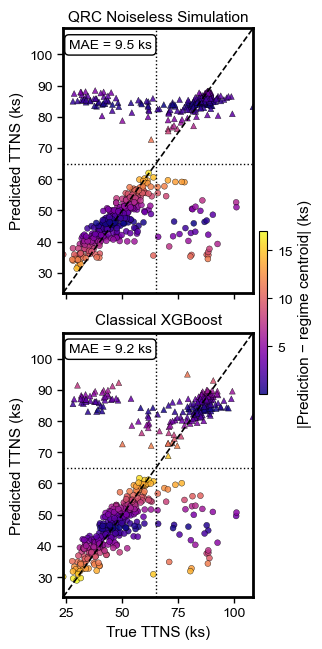

In [20]:
# ── Cell: Predicted vs True TTNS — QRC+Ridge vs. classical XGBoost ───────────
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---------------------------------------------------------------- global style
mpl.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "font.style": "normal",
    "mathtext.default": "regular",
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 11,
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

# Panel 1: QRC + Ridge
qrc_pred = ensemble_pred
qrc_mae  = mean_absolute_error(y_test_np, qrc_pred)

# Panel 2: classical XGBoost baseline
xgb_pred = final_predictions
xgb_mae  = mean_absolute_error(y_test_np, xgb_pred)

assigned_center = np.where(clf_test_labels == 0, centers[0], centers[1])
qrc_color_vals = np.abs(qrc_pred - assigned_center) / 1000.0  # ks
xgb_color_vals = np.abs(xgb_pred - assigned_center) / 1000.0  # ks

vmin = min(qrc_color_vals.min(), xgb_color_vals.min())
vmax = max(qrc_color_vals.max(), xgb_color_vals.max())

lims = [
    min(y_test_np.min(), qrc_pred.min(), xgb_pred.min()) / 1000.0,
    max(y_test_np.max(), qrc_pred.max(), xgb_pred.max()) / 1000.0,
]

regime_marker = {0: "o", 1: "^"}

# Stacked vertically: single-column width, taller height for two rows
fig, axes = plt.subplots(2, 1, figsize=(3.34, 6.6), sharex=True, sharey=True)

panels = [
    (axes[0], "QRC Noiseless Simulation", qrc_pred, qrc_color_vals, qrc_mae),
    (axes[1], "Classical XGBoost",        xgb_pred, xgb_color_vals, xgb_mae),
]

sc = None
for ax, title, pred, color_vals, mae in panels:
    for regime in (0, 1):
        mask = clf_test_labels == regime
        sc = ax.scatter(
            y_test_np[mask] / 1000.0, pred[mask] / 1000.0,
            c=color_vals[mask], cmap="plasma",
            marker=regime_marker[regime],
            s=18, alpha=0.85,
            edgecolors="black", linewidths=0.3,
            vmin=vmin, vmax=vmax,
        )

    ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.2, zorder=1)
    ax.axhline(boundary / 1000.0, color="black", linestyle=":", linewidth=1.0, zorder=1)
    ax.axvline(boundary / 1000.0, color="black", linestyle=":", linewidth=1.0, zorder=1)

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_ylabel("Predicted TTNS (ks)")
    ax.set_title(title, fontweight="normal", fontstyle="normal")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(2)

    ax.grid(False)
    ax.tick_params(direction="out", width=1, length=4)

    ax.text(
        0.03, 0.96, f"MAE = {mae/1000:.1f} ks",
        transform=ax.transAxes, va="top", fontsize=10,
        fontweight="normal", fontstyle="normal",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", linewidth=1),
    )

axes[-1].set_xlabel("True TTNS (ks)")

fig.tight_layout(rect=[0, 0, 0.86, 1])
cbar = fig.colorbar(sc, ax=axes, fraction=0.04, pad=0.03)
cbar.set_label("|Prediction \u2212 regime centroid| (ks)")
cbar.ax.tick_params(labelsize=10)

# ---------------------------------------------------------------- save/export
fig.savefig("qrc_vs_xgb_ttns.png", dpi=600, bbox_inches="tight", pad_inches=0.02)

plt.show()

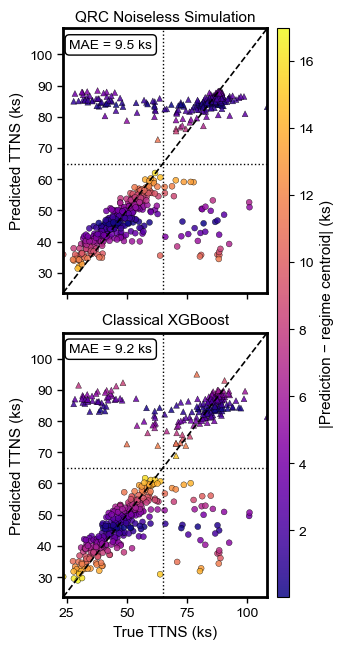

In [21]:
# ── Cell: Predicted vs True TTNS — QRC+Ridge vs. classical XGBoost ───────────
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---------------------------------------------------------------- global style
mpl.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "font.style": "normal",
    "mathtext.default": "regular",
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 11,
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

# Panel 1: QRC + Ridge
qrc_pred = ensemble_pred
qrc_mae  = mean_absolute_error(y_test_np, qrc_pred)

# Panel 2: classical XGBoost baseline
xgb_pred = final_predictions
xgb_mae  = mean_absolute_error(y_test_np, xgb_pred)

assigned_center = np.where(clf_test_labels == 0, centers[0], centers[1])
qrc_color_vals = np.abs(qrc_pred - assigned_center) / 1000.0  # ks
xgb_color_vals = np.abs(xgb_pred - assigned_center) / 1000.0  # ks

vmin = min(qrc_color_vals.min(), xgb_color_vals.min())
vmax = max(qrc_color_vals.max(), xgb_color_vals.max())

lims = [
    min(y_test_np.min(), qrc_pred.min(), xgb_pred.min()) / 1000.0,
    max(y_test_np.max(), qrc_pred.max(), xgb_pred.max()) / 1000.0,
]

regime_marker = {0: "o", 1: "^"}

fig, axes = plt.subplots(2, 1, figsize=(3.34, 6.6), sharex=True, sharey=True)

panels = [
    (axes[0], "QRC Noiseless Simulation", qrc_pred, qrc_color_vals, qrc_mae),
    (axes[1], "Classical XGBoost",        xgb_pred, xgb_color_vals, xgb_mae),
]

sc = None
for ax, title, pred, color_vals, mae in panels:
    for regime in (0, 1):
        mask = clf_test_labels == regime
        sc = ax.scatter(
            y_test_np[mask] / 1000.0, pred[mask] / 1000.0,
            c=color_vals[mask], cmap="plasma",
            marker=regime_marker[regime],
            s=18, alpha=0.85,
            edgecolors="black", linewidths=0.3,
            vmin=vmin, vmax=vmax,
        )

    ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.2, zorder=1)
    ax.axhline(boundary / 1000.0, color="black", linestyle=":", linewidth=1.0, zorder=1)
    ax.axvline(boundary / 1000.0, color="black", linestyle=":", linewidth=1.0, zorder=1)

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_ylabel("Predicted TTNS (ks)")
    ax.set_title(title, fontweight="normal", fontstyle="normal")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(2)

    ax.grid(False)
    ax.tick_params(direction="out", width=1, length=4)

    ax.text(
        0.03, 0.96, f"MAE = {mae/1000:.1f} ks",
        transform=ax.transAxes, va="top", fontsize=10,
        fontweight="normal", fontstyle="normal",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", linewidth=1),
    )

axes[-1].set_xlabel("True TTNS (ks)")

fig.tight_layout(rect=[0, 0, 0.86, 1])

# ------------------------------------------------------ colorbar, aligned to
# the exact vertical extent of both panels (top of panel 1 -> bottom of panel 2)
fig.canvas.draw()  # finalize axes positions before reading them
pos_top = axes[0].get_position()
pos_bot = axes[-1].get_position()
cbar_ax = fig.add_axes([
    pos_top.x1 + 0.03,      # x0: just right of the panels
    pos_bot.y0,             # y0: bottom of the lower panel
    0.035,                  # width
    pos_top.y1 - pos_bot.y0 # height: spans top panel's top to bottom panel's bottom
])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("|Prediction \u2212 regime centroid| (ks)")
cbar.ax.tick_params(labelsize=10)

# ---------------------------------------------------------------- save/export
fig.savefig("qrc_vs_xgb_ttns.png", dpi=600, bbox_inches="tight", pad_inches=0.02)

plt.show()